In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import yfinance as yf
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from datetime import timedelta

In [4]:
BTC = yf.Ticker("BTC-USD")
btc_prices = BTC.history(period = "10y")[["Close"]].dropna().rename(columns={"Close":"close"})

print(btc_prices.tail())

                                   close
Date                                    
2025-09-14 00:00:00+00:00  115407.656250
2025-09-15 00:00:00+00:00  115444.875000
2025-09-16 00:00:00+00:00  116843.187500
2025-09-17 00:00:00+00:00  116468.507812
2025-09-18 00:00:00+00:00  117356.710938


In [5]:
N_sim = 2000
seed = 42

forecast_horizon = 100
n_estimators = 200
btc_prices.index = pd.to_datetime(btc_prices.index)
btc_prices = btc_prices.sort_index()

In [6]:
btc_prices["logp"] = np.log(btc_prices['close'])
btc_prices["logr"] = btc_prices['logp'].diff()
btc_prices = btc_prices.dropna()
print(btc_prices.head())

                                close      logp      logr
Date                                                     
2015-09-19 00:00:00+00:00  231.492996  5.444550 -0.006382
2015-09-20 00:00:00+00:00  231.212006  5.443335 -0.001215
2015-09-21 00:00:00+00:00  227.085007  5.425324 -0.018011
2015-09-22 00:00:00+00:00  230.617996  5.440763  0.015438
2015-09-23 00:00:00+00:00  230.283005  5.439309 -0.001454


In [7]:
logrets = btc_prices['logr']
dt = 1.0
mu_hat = logrets.mean() / dt + 0.5 * (logrets.std() ** 2)
sigma_hat = logrets.std() / np.sqrt(dt)

print(f"Estymowane (na rzokładzie dziennym): mu = {mu_hat}, sigma = {sigma_hat}")

Estymowane (na rzokładzie dziennym): mu = 0.002337076256920421, sigma = 0.03560357020786377


In [8]:
lags = [1, 2, 3, 5]
for l in lags:
    btc_prices[f"lag_r_{l}"] = btc_prices["logr"].shift(l)
btc_prices["vol_7"] = btc_prices["logr"].rolling(7).std()
btc_prices["sma_7"] = btc_prices["logp"].rolling(7).mean()
btc_prices["close_last"] = btc_prices["close"]
btc_prices = btc_prices.dropna()
print(btc_prices.head(15))

                                close      logp      logr   lag_r_1   lag_r_2  \
Date                                                                            
2015-09-25 00:00:00+00:00  235.143997  5.460198  0.002619  0.018270 -0.001454   
2015-09-26 00:00:00+00:00  234.339996  5.456773 -0.003425  0.002619  0.018270   
2015-09-27 00:00:00+00:00  232.757004  5.449995 -0.006778 -0.003425  0.002619   
2015-09-28 00:00:00+00:00  239.141998  5.477058  0.027063 -0.006778 -0.003425   
2015-09-29 00:00:00+00:00  236.686996  5.466739 -0.010319  0.027063 -0.006778   
2015-09-30 00:00:00+00:00  236.059998  5.464086 -0.002653 -0.010319  0.027063   
2015-10-01 00:00:00+00:00  237.548996  5.470374  0.006288 -0.002653 -0.010319   
2015-10-02 00:00:00+00:00  237.292999  5.469296 -0.001078  0.006288 -0.002653   
2015-10-03 00:00:00+00:00  238.729996  5.475333  0.006038 -0.001078  0.006288   
2015-10-04 00:00:00+00:00  238.259003  5.473358 -0.001975  0.006038 -0.001078   
2015-10-05 00:00:00+00:00  2

In [9]:
btc_prices["E_log_next_from_prev"] = btc_prices["logp"].shift(1) + (mu_hat - 0.5 * sigma_hat ** 2) * dt
btc_prices["eps_next"] = btc_prices["logp"] - btc_prices["E_log_next_from_prev"]
btc_prices = btc_prices.dropna()

In [10]:
feature_cols = [f"lag_r_{l}" for l in lags] + ["vol_7", "sma_7", "close_last"]
X = btc_prices[feature_cols].copy()
y = btc_prices["eps_next"].copy()

In [11]:
train_end_idx = len(X) - forecast_horizon
if train_end_idx <= 50:
    train_end_idx = int(len(X) * 0.8)
X_train, y_train = X.iloc[:train_end_idx], y.iloc[:train_end_idx]
X_val, y_val = X.iloc[train_end_idx:], y.iloc[train_end_idx:]

In [12]:
rf = RandomForestRegressor(n_estimators = n_estimators, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
val_rmse = np.nan
if len(y_val) > 0:
    y_val_pred = rf.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(val_rmse)

0.015300480108685009


In [14]:
last_row = btc_prices.iloc[-1].copy()
pred_dates = []
pred_logp = []
pred_price = []
pred_eps = []

current_row = last_row.copy()

def E_log_next(logp_current):
    return logp_current + (mu_hat - 0.5 * sigma_hat ** 2) * dt

last_date = current_row.name
for h in range(1, forecast_horizon + 1):
    feat = {}
    for l in lags:
        feat[f"lag_r_{l}"] = current_row.get(f"lag_r_{l}")
    feat["vol_7"] = current_row["vol_7"]
    feat["sma_7"] = current_row["sma_7"]
    feat["close_last"] = current_row["close_last"]
    X_next = pd.DataFrame([feat])

    eps_pred = rf.predict(X_next)[0]

    logp_current = current_row["logp"]
    E_log = E_log_next(logp_current)
    pred_log = E_log + eps_pred
    pred_p = float(np.exp(pred_log))

    pred_date = last_date + timedelta(days = h)
    pred_dates.append(pred_date)
    pred_logp.append(pred_log)
    pred_price.append(pred_p)
    pred_eps.append(eps_pred)


    pred_logret = pred_log - logp_current
    new_row = current_row.copy()
    new_row["logp"] = pred_log
    new_row["close_last"] = pred_p

    for l in sorted (lags, reverse = True):
        if l == 1:
            new_row["lag_r_1"] = pred_logret
        else:
            new_row[f"lag_r_{l}"] = current_row.get(f"lag_r_{l-1}")

    recent = []
    for i in range(1, 7):
        col = f"lag_r_{i}"
        recent.append(current_row.get(col) if col in current_row.index else 0.0)
    vol_window = np.array(recent[:6] + [pred_logret])
    new_row["vol_7"] = float(np.std(vol_window, ddof=0))
    new_row["sma_7"] = float(current_row["sma_7"] + (pred_log - current_row["logp"]) / 7.0)

    current_row = new_row.copy()

In [15]:
forecast_df = pd.DataFrame({
    'date': pd.to_datetime(pred_dates),
    'pred_logp': pred_logp,
    'pred_price': pred_price,
    'pred_eps': pred_eps
}).set_index("date")


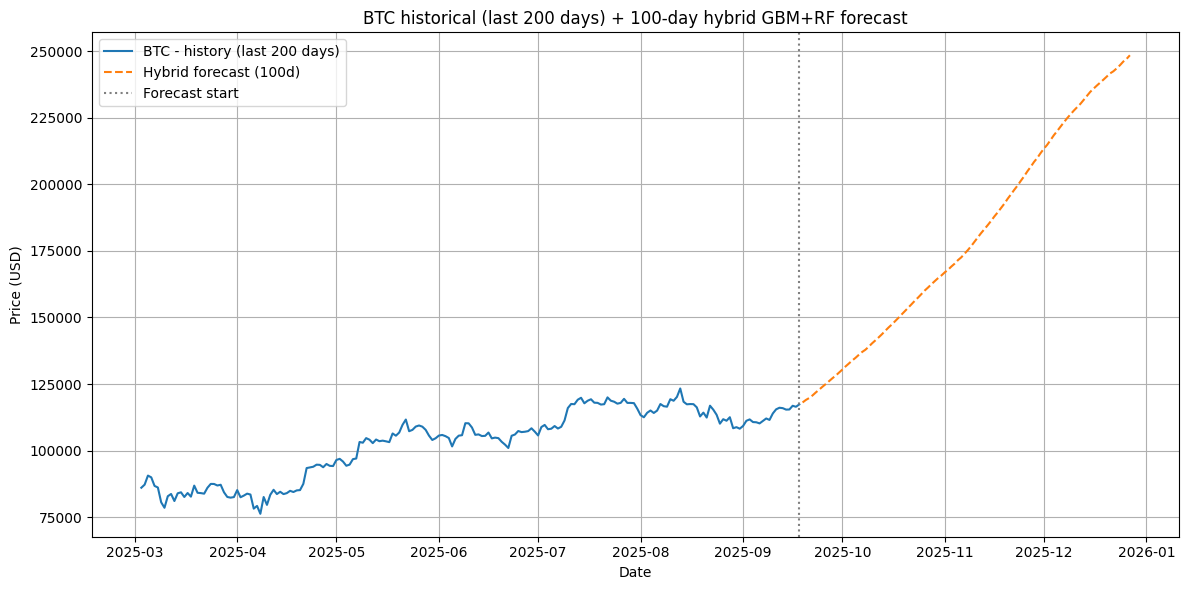

In [16]:
plt.figure(figsize=(12,6))
plt.plot(btc_prices['close'][-200:].index, btc_prices['close'][-200:].values, label='BTC - history (last 200 days)')
plt.plot(forecast_df.index, forecast_df['pred_price'], linestyle='--', label=f'Hybrid forecast ({forecast_horizon}d)')
plt.axvline(btc_prices.index[-1], color='gray', linestyle=':', label='Forecast start')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title(f'BTC historical (last 200 days) + {forecast_horizon}-day hybrid GBM+RF forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
print(forecast_df.head())

                           pred_logp     pred_price  pred_eps
date                                                         
2025-09-19 00:00:00+00:00  11.679235  118093.860934  0.004558
2025-09-20 00:00:00+00:00  11.687168  119034.394967  0.006229
2025-09-21 00:00:00+00:00  11.693140  119747.442933  0.004269
2025-09-22 00:00:00+00:00  11.701257  120723.347054  0.006413
2025-09-23 00:00:00+00:00  11.710518  121846.607988  0.007558


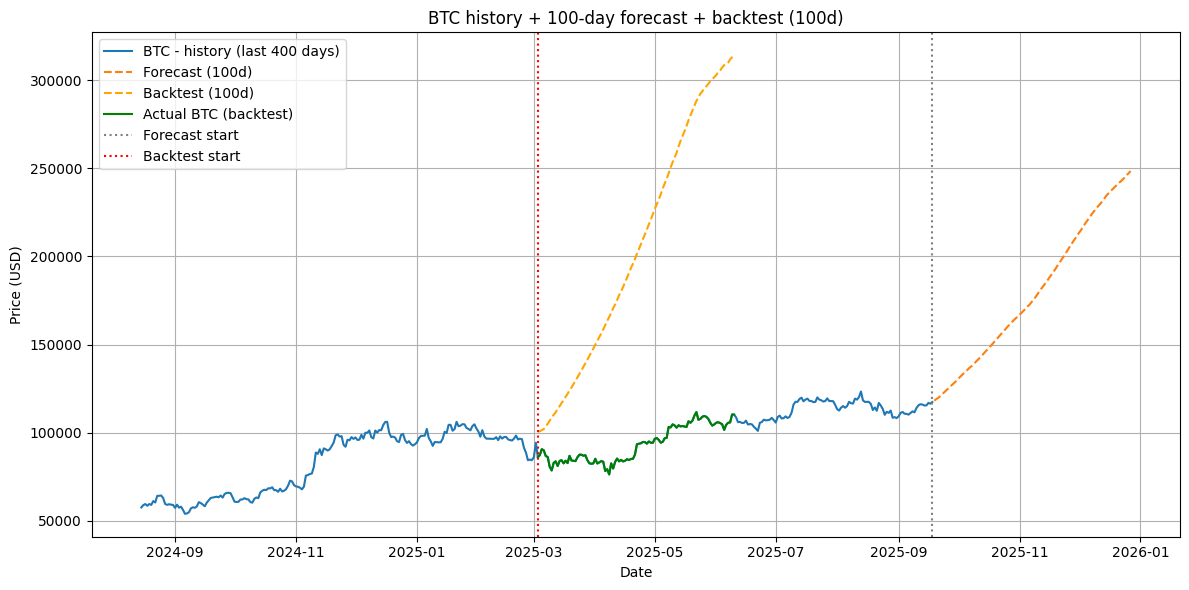

In [18]:

backtest_horizon = 100  
backtest_start = len(btc_prices) - 2 * backtest_horizon  


btc_train = btc_prices.iloc[:backtest_start].copy()
btc_test = btc_prices.iloc[backtest_start:].copy()

X_train_bt = btc_train[feature_cols]
y_train_bt = btc_train["eps_next"]

rf_bt = RandomForestRegressor(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
rf_bt.fit(X_train_bt, y_train_bt)


last_row_bt = btc_train.iloc[-1].copy()
last_date_bt = last_row_bt.name

pred_dates_bt = []
pred_price_bt = []

current_row_bt = last_row_bt.copy()

for h in range(1, backtest_horizon + 1):
    feat = {f"lag_r_{l}": current_row_bt.get(f"lag_r_{l}") for l in lags}
    feat["vol_7"] = current_row_bt["vol_7"]
    feat["sma_7"] = current_row_bt["sma_7"]
    feat["close_last"] = current_row_bt["close_last"]

    X_next = pd.DataFrame([feat])
    eps_pred = rf_bt.predict(X_next)[0]

    logp_current = current_row_bt["logp"]
    E_log = E_log_next(logp_current)
    pred_log = E_log + eps_pred
    pred_p = float(np.exp(pred_log))

    pred_date = last_date_bt + timedelta(days=h)
    pred_dates_bt.append(pred_date)
    pred_price_bt.append(pred_p)

    pred_logret = pred_log - logp_current
    new_row = current_row_bt.copy()
    new_row["logp"] = pred_log
    new_row["close_last"] = pred_p

    for l in sorted(lags, reverse=True):
        if l == 1:
            new_row["lag_r_1"] = pred_logret
        else:
            new_row[f"lag_r_{l}"] = current_row_bt.get(f"lag_r_{l-1}")

    recent = []
    for i in range(1, 7):
        col = f"lag_r_{i}"
        recent.append(current_row_bt.get(col) if col in current_row_bt.index else 0.0)
    vol_window = np.array(recent[:6] + [pred_logret])
    new_row["vol_7"] = float(np.std(vol_window, ddof=0))
    new_row["sma_7"] = float(current_row_bt["sma_7"] + (pred_log - current_row_bt["logp"]) / 7.0)

    current_row_bt = new_row.copy()


backtest_df = pd.DataFrame({
    'date': pd.to_datetime(pred_dates_bt),
    'pred_price': pred_price_bt
}).set_index("date")

plt.figure(figsize=(12,6))
plt.plot(btc_prices['close'][-400:].index, btc_prices['close'][-400:].values, label='BTC - history (last 400 days)')
plt.plot(forecast_df.index, forecast_df['pred_price'], linestyle='--', label=f'Forecast ({forecast_horizon}d)')
plt.plot(backtest_df.index, backtest_df['pred_price'], linestyle='--', color='orange', label=f'Backtest ({backtest_horizon}d)')
plt.plot(btc_test.index[:backtest_horizon], btc_test['close'][:backtest_horizon], color='green', label='Actual BTC (backtest)')
plt.axvline(btc_prices.index[-1], color='gray', linestyle=':', label='Forecast start')
plt.axvline(btc_test.index[0], color='red', linestyle=':', label='Backtest start')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title(f'BTC history + {forecast_horizon}-day forecast + backtest ({backtest_horizon}d)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
